In [1]:
import openassetpricing as oap
from tqdm import tqdm
import pandas as pd
import numpy as np

In [2]:
openap = oap.OpenAP()

In [37]:
signal_doc = openap.dl_signal_doc('pandas')

In [38]:
all_features = signal_doc.Acronym.tolist()

In [ ]:
import wrds

db = wrds.Connection(wrds_username='francoisgoybet')

query = f"""
select
    permno,
    date,
    ret,
    prc,
    shrout,
    abs(prc*shrout)/1e6 as market_cap_musd
from crsp.msf
where abs(prc*shrout)/1e6 > 10
and date >= '1990-01-01'
order by permno, date
"""

crsp_df = db.raw_sql(query)
crsp_df['date'] = pd.to_datetime(crsp_df['date'])

crsp_df['yyyymm'] = crsp_df['date'].dt.strftime('%Y%m')
crsp_df = crsp_df[['permno', 'yyyymm', 'ret', 'market_cap_musd']]

crsp_df['yyyymm'] = crsp_df['yyyymm'].astype(str)  # ensure string for merge
crsp_df = crsp_df.sort_values(['permno', 'yyyymm'])

crsp_df['ret_1m'] = crsp_df.groupby('permno')['ret'].shift(-1)
crsp_df['ret_3m'] = crsp_df.groupby('permno')['ret'].shift(-3)
crsp_df['ret_6m'] = crsp_df.groupby('permno')['ret'].shift(-6)

Loading library list...
Done


In [4]:
crsp_df

,permno,yyyymm,ret,ret_1m,ret_3m,ret_6m
0,10078,199605,0.154378,-0.05988,-0.004577,-0.045082
1,10078,199606,-0.05988,-0.072187,0.142529,0.23601
2,10078,199607,-0.072187,-0.004577,-0.018109,-0.027559
3,10078,199608,-0.004577,0.142529,-0.045082,-0.064777
4,10078,199609,0.142529,-0.018109,0.23601,-0.002165
...,...,...,...,...,...,...
161017,93436,202408,-0.077391,0.221942,0.381469,<NA>
161018,93436,202409,0.221942,-0.045025,0.170008,<NA>
161019,93436,202410,-0.045025,0.381469,<NA>,<NA>
161020,93436,202411,0.381469,0.170008,<NA>,<NA>


<Axes: xlabel='yyyymm'>

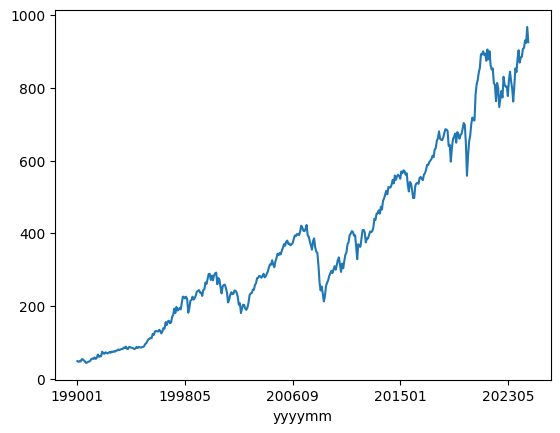

In [42]:
crsp_df.groupby('yyyymm').size().plot()

In [43]:
import pandas as pd
from tqdm import tqdm
import openassetpricing as oap

# -----------------------------
# INIT
# -----------------------------
openap = oap.OpenAP()

base = crsp_df.copy()
base['permno'] = base['permno'].astype(int)
base['yyyymm'] = base['yyyymm'].astype(int)

signals = signal_doc.Acronym.tolist()

chunk_size = 20

output_prefix = "ml_dataset_part_"

# -----------------------------
# FUNCTION
# -----------------------------
def load_features(batch_signals):
    df = openap.dl_signal('pandas', batch_signals)

    df['permno'] = df['permno'].astype(int)
    df['yyyymm'] = df['yyyymm'].astype(int)

    return df

# -----------------------------
# MAIN LOOP (MULTI FILE OUTPUT)
# -----------------------------
for i in tqdm(range(0, len(signals), chunk_size), desc="OSAP batching"):
    # if i < 120:
    #     continue
    print(f"Processing signals {i} to {min(i+chunk_size, len(signals))}...")
    batch = signals[i:i+chunk_size]

    feat = load_features(batch)

    # SAFE LEFT MERGE
    base_chunk = base.merge(
        feat,
        on=['permno', 'yyyymm'],
        how='left'
    )

    # -----------------------------
    # 💾 SAVE EACH CHUNK SEPARATELY
    # -----------------------------
    base_chunk.to_parquet(
        f"{output_prefix}{i:04d}.parquet",
        index=False
    )

    del feat, base_chunk

print("DONE — all chunks saved")

OSAP batching:   0%|          | 0/17 [00:00<?, ?it/s]

Processing signals 0 to 20...
One or more input predictors are not available.

Data is downloaded: 5 mins


OSAP batching:   6%|▌         | 1/17 [04:59<1:19:59, 299.95s/it]

Processing signals 20 to 40...

Data is downloaded: 2 mins


OSAP batching:  12%|█▏        | 2/17 [07:30<53:05, 212.36s/it]  

...

Processing signals 220 to 240...
One or more input predictors are not available.

Data is downloaded: 0s
Processing signals 240 to 260...
One or more input predictors are not available.

Data is downloaded: 0s


OSAP batching:  88%|████████▊ | 15/17 [35:59<01:46, 53.09s/it]

Processing signals 260 to 280...
One or more input predictors are not available.

Data is downloaded: 0s
Processing signals 280 to 300...
One or more input predictors are not available.

Data is downloaded: 0s


OSAP batching: 100%|██████████| 17/17 [35:59<00:00, 127.03s/it]


Processing signals 300 to 320...
One or more input predictors are not available.

Data is downloaded: 0s
Processing signals 320 to 331...
One or more input predictors are not available.

Data is downloaded: 0s
DONE — all chunks saved


In [9]:
df = pd.read_parquet("ml_dataset_part_0020.parquet")

In [7]:
import pandas as pd
import glob

files = glob.glob("ml_dataset_part_*.parquet")

dfs = [pd.read_parquet(f) for f in files]
# merge them on permno	yyyymm	ret	ret_1m	ret_3m	ret_6m
# we can use reduce to merge them iteratively
from functools import reduce
from functools import reduce
def merge_dfs(left, right):
    return pd.merge(left, right, on=['permno', 'yyyymm', 'ret', 'ret_1m', 'ret_3m', 'ret_6m'], how='outer')
final_df = reduce(merge_dfs, dfs).drop_duplicates(subset=['permno', 'yyyymm']) 

In [8]:
# check the percenage of missing values in each column
missing_percentage = final_df.isnull().mean() * 100
print(missing_percentage.sort_values(ascending=False))
# check number and proportiion of columns with more than x% missing values
threshold = 20
num_cols_above_threshold = (missing_percentage > threshold).sum()
total_cols = len(missing_percentage)
proportion_above_threshold = num_cols_above_threshold / total_cols * 100
print(f"Number of columns with more than {threshold}% missing values: {num_cols_above_threshold}")
print(f"Proportion of columns with more than {threshold}% missing values: {proportion_above_threshold:.2f}%")

ChNAnalyst     100.000000
CitationsRD    100.000000
IndRetBig      100.000000
EarnSupBig     100.000000
Activism1       99.874390
                  ...    
betaVIX          0.014778
IdioVol3F        0.014778
MaxRet           0.007389
permno           0.000000
yyyymm           0.000000
Length: 110, dtype: float64
Number of columns with more than 20% missing values: 32
Proportion of columns with more than 20% missing values: 29.09%


In [15]:
df.to_parquet("final_ml_dataset.parquet", index=False)

In [16]:
signal_doc.to_parquet("../data/signal_doc.parquet", index=False)


In [16]:
import numpy as np
import pandas as pd

def encode_labels_argsort(y: pd.Series, groups: list[int]) -> np.ndarray:
    """
    Assign per-group ranks using argsort.
    0 = worst, higher = better.
    """
    out = np.empty(len(y), dtype=np.int64)
    cursor = 0

    for g in groups:
        sl = slice(cursor, cursor + g)
        y_group = y.iloc[sl].to_numpy()

        # argsort twice = rank
        ranks = np.argsort(np.argsort(y_group))

        out[sl] = ranks
        cursor += g

    return out

In [19]:
encode_labels_argsort(pd.Series([.5, 1, -1, 5, 2]), [2,3])

array([0, 1, 0, 2, 1])

In [26]:
df_test = pd.read_parquet("../data/dataset.parquet")

In [31]:
df_test.sort_values(['yyyymm', 'permno'], inplace=True)
df_test.groupby('yyyymm').size()

yyyymm
199509      2
199510      2
199511      2
199512      3
199601      2
         ... 
202408    119
202409    119
202410    111
202411    119
202412    111
Length: 352, dtype: int64

<Axes: xlabel='yyyymm'>

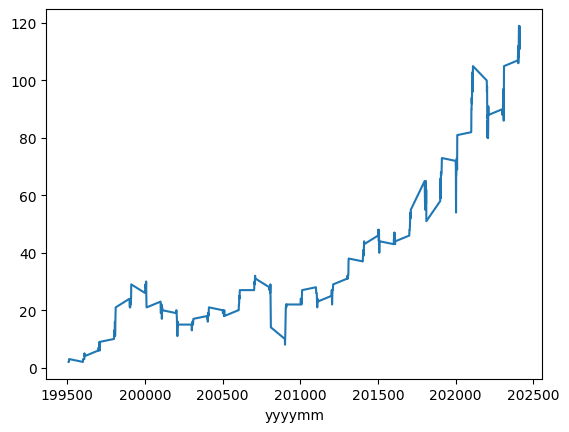

In [32]:
# plot number of stock per month
df_test.groupby('yyyymm').size().plot()